# 01 — Configuração e Extração dos Dados do SINAN

## Objetivo

Este notebook corresponde à etapa inicial do pipeline de processamento dos dados do **Sistema de Informação de Agravos de Notificação (SINAN)** para análise epidemiológica da dengue.

Seu objetivo é preparar o ambiente de execução e realizar a obtenção dos dados brutos que serão utilizados nas etapas posteriores do processamento.

De forma geral, este notebook é responsável por:

1. definir o **ano de referência** utilizado no processamento;
2. configurar os **diretórios do projeto** para armazenamento dos dados;
3. criar automaticamente as pastas necessárias, quando inexistentes;
4. obter o arquivo de dados de dengue disponibilizado pelo SINAN/DATASUS;
5. armazenar o arquivo original na área de **dados brutos (`data_raw`)**;
6. converter o arquivo do formato **DBC para DBF**, quando necessário;
7. disponibilizar o arquivo resultante para a etapa seguinte de pré-processamento.

## Organização no pipeline

O fluxo iniciado neste notebook pode ser representado da seguinte forma:

SINAN / DATASUS  
↓  
Download do arquivo DBC  
↓  
Armazenamento em `data_raw/SINAN/{ANO}`  
↓  
Conversão DBC → DBF  
↓  
Dados brutos disponíveis para pré-processamento

## Observação

Este notebook é destinado exclusivamente à **configuração e aquisição dos dados brutos**. Operações de limpeza, padronização, transformação de variáveis e geração de indicadores epidemiológicos são realizadas em notebooks posteriores, preservando a separação entre as etapas de aquisição, processamento e análise dos dados.



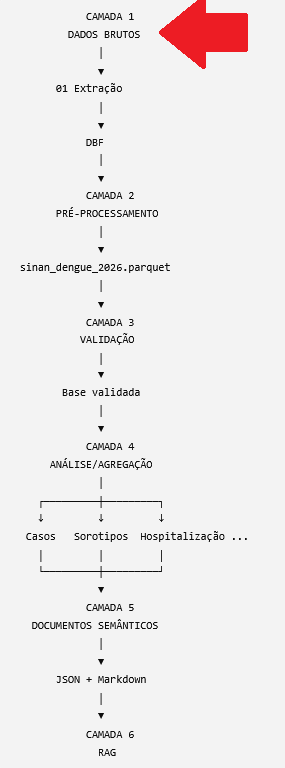

# Importação das bibliotecas

In [3]:
!pip install datasus-dbc dbfread pandas

import os
import pandas as pd
from dbfread import DBF
from google.colab import drive
import datasus_dbc
from datetime import datetime

Montagem do drive

In [4]:
from google.colab import drive
import os

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Baixar o arquivo direto do site do SINAN. Para baixá-lo https://datasus.saude.gov.br/transferencia-de-arquivos/#  Tem que aguardar até aparecer um link chamado arquivo. Para ir mais rápido eu utilizei o filezilla é um cliente ftp, com isso, é só digitar ftp://ftp.datasus.gov.br/dissemin/publicos/SINAN/ no HOST e conectar. Clicar e arrastar para a esquerda (pasta destino) os arquivos do servidor. Por exemplo, o arquivo DENGBR24. Repare que como ainda estamos em 2026 os arquivos estão na pasta PRELIM e não na pasta FINAIS. Se for baixar dos outros anos por exemplo DENGBR24 utilize a pasta FINAIS ftp://ftp.datasus.gov.br/dissemin/publicos/SINAN/DADOS/FINAIS/DENGBR26.dbc

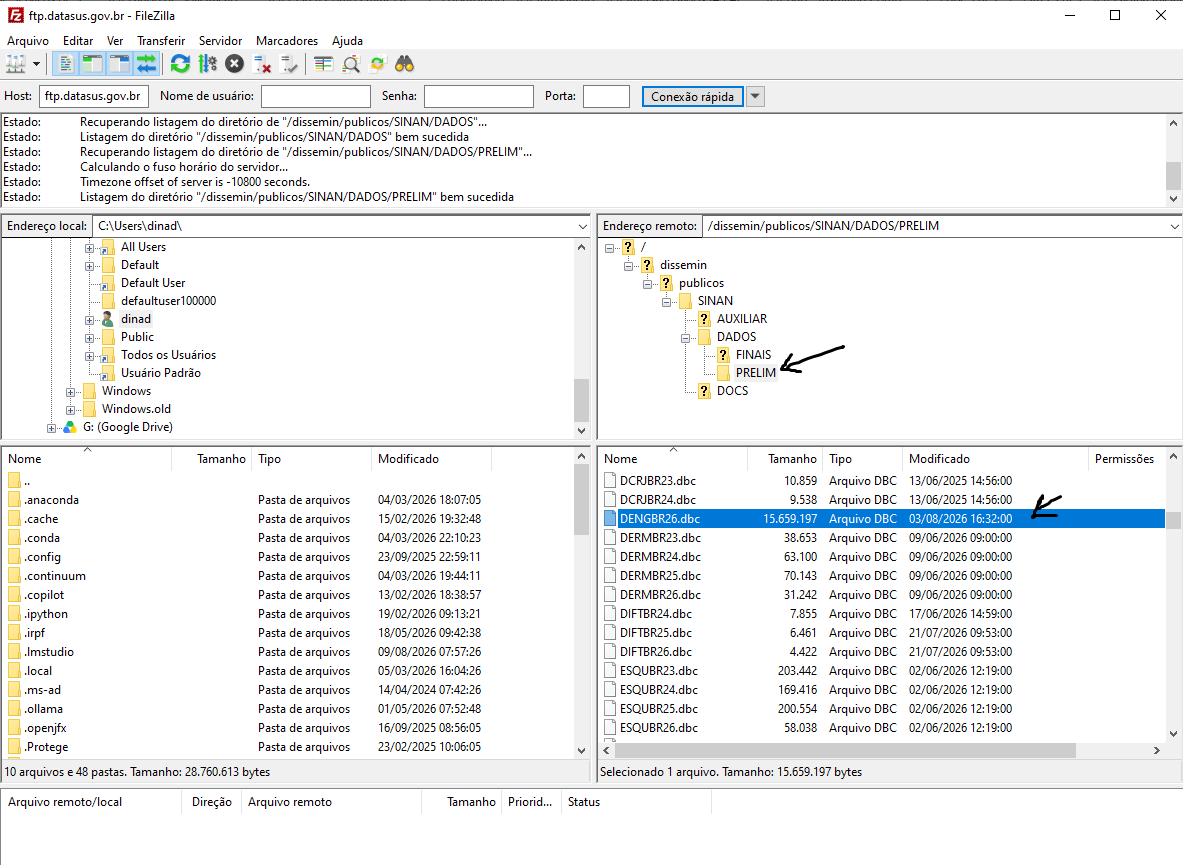

# 1 - Configuração e criação das pastas

Temos três conceitos bem separados:

| Variável          | Responsabilidade                        |
| ----------------- | --------------------------------------- |
| `PASTA_RAW`       | dados originais/brutos do SINAN         |
| `PASTA_PROCESSED` | dados após limpeza e padronização       |
| `PASTA_DOCS`      | documentos semânticos destinados ao RAG |


In [5]:
from pathlib import Path

# ============================================================
# CONFIGURAÇÕES GERAIS
# ============================================================

ANO = 2026
ANO_CURTO = str(ANO)[-2:]

# ============================================================
# DIRETÓRIO BASE DO PROJETO
# ============================================================

PASTA_PROJETO = Path(
    "/content/drive/MyDrive/Doutorado/arbovirus_rag"
)

# ============================================================
# DIRETÓRIOS DO SINAN
# ============================================================

PASTA_RAW = (
    PASTA_PROJETO
    / "data_raw"
    / "SINAN"
    / str(ANO)
)

PASTA_PROCESSED = (
    PASTA_PROJETO
    / "data_processed"
    / "SINAN"
    / str(ANO)
)

PASTA_DOCS = (
    PASTA_PROJETO
    / "data_docs"
    / "SINAN"
    / str(ANO)
)

# ============================================================
# CRIAÇÃO DAS PASTAS
# ============================================================

for pasta in [
    PASTA_RAW,
    PASTA_PROCESSED,
    PASTA_DOCS
]:
    pasta.mkdir(
        parents=True,
        exist_ok=True
    )

# ============================================================
# ARQUIVOS BRUTOS DO SINAN
# ============================================================

ARQUIVO_DBC = (
    PASTA_RAW
    / f"DENGBR{ANO_CURTO}.dbc"
)

ARQUIVO_DBF = (
    PASTA_RAW
    / f"DENGBR{ANO_CURTO}.dbf"
)

# ============================================================
# RESUMO DA CONFIGURAÇÃO
# ============================================================

print(f"Ano de análise: {ANO}")
print(f"Dados brutos: {PASTA_RAW}")
print(f"Dados processados: {PASTA_PROCESSED}")
print(f"Documentos semânticos: {PASTA_DOCS}")

print()
print(f"Arquivo DBC: {ARQUIVO_DBC}")
print(f"Arquivo DBF: {ARQUIVO_DBF}")



Ano de análise: 2026
Dados brutos: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/SINAN/2026
Dados processados: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_processed/SINAN/2026
Documentos semânticos: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_docs/SINAN/2026

Arquivo DBC: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/SINAN/2026/DENGBR26.dbc
Arquivo DBF: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/SINAN/2026/DENGBR26.dbf


# 2 - Salva o arquivo dbc da dengue na pasta:
 /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/
 Eu tive que utilizar o filezila pois o código abaixo não funcionou. Cliquei e arrastei o arquivo DENGBR26.dbc para a pasta /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/

In [6]:
# ============================================================
# DOWNLOAD DOS DADOS DO SINAN
# ============================================================

URL_DBC = (
    "ftp://ftp.datasus.gov.br/"
    "dissemin/publicos/SINAN/DADOS/PRELIM/"
    f"DENGBR{ANO_CURTO}.dbc"
)

print(f"Baixando dados do SINAN referentes ao ano de {ANO}...")
print(f"Origem: {URL_DBC}")
print(f"Destino: {ARQUIVO_DBC}")

!wget -O "{ARQUIVO_DBC}" "{URL_DBC}"

Baixando dados do SINAN referentes ao ano de 2026...
Origem: ftp://ftp.datasus.gov.br/dissemin/publicos/SINAN/DADOS/PRELIM/DENGBR26.dbc
Destino: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/SINAN/2026/DENGBR26.dbc
--2026-08-30 19:25:17--  ftp://ftp.datasus.gov.br/dissemin/publicos/SINAN/DADOS/PRELIM/DENGBR26.dbc
           => ‘/content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/SINAN/2026/DENGBR26.dbc’
Resolving ftp.datasus.gov.br (ftp.datasus.gov.br)... 189.28.143.164
Connecting to ftp.datasus.gov.br (ftp.datasus.gov.br)|189.28.143.164|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /dissemin/publicos/SINAN/DADOS/PRELIM ... done.
==> SIZE DENGBR26.dbc ... 21897165
==> PASV ... done.    ==> RETR DENGBR26.dbc ... done.
Length: 21897165 (21M) (unauthoritative)

DENGBR26.dbc        100%[===================>]  20.88M   776KB/s    in 29s     

2026-08-30 19:25:48 (742 KB/s) - ‘/content/drive/My

# 3 - Verifica se o dbc existe

In [7]:
# ============================================================
# VERIFICAÇÃO DO ARQUIVO DBC
# ============================================================

if not ARQUIVO_DBC.exists():
    raise FileNotFoundError(
        f"Arquivo DBC não encontrado: {ARQUIVO_DBC}"
    )

print(f"Arquivo DBC encontrado: {ARQUIVO_DBC}")

Arquivo DBC encontrado: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/SINAN/2026/DENGBR26.dbc


# 4 - REMOVER DBF ANTIGO, CASO EXISTA

In [8]:
# ============================================================
# REMOÇÃO DE ARQUIVO DBF EXISTENTE
# ============================================================

if ARQUIVO_DBF.exists():
    print(f"DBF existente encontrado: {ARQUIVO_DBF}")
    print("Removendo versão anterior...")

    ARQUIVO_DBF.unlink()

    print("DBF anterior removido.")
else:
    print("Nenhum arquivo DBF anterior encontrado.")

Nenhum arquivo DBF anterior encontrado.


# 5 - CONVERSÃO DBC → DBF

In [9]:
# ============================================================
# CONVERSÃO DO ARQUIVO DBC PARA DBF
# ============================================================

print(f"\nConvertendo {ARQUIVO_DBC}...")

datasus_dbc.decompress(
    str(ARQUIVO_DBC),
    str(ARQUIVO_DBF)
)

print(f"Arquivo convertido com sucesso: {ARQUIVO_DBF}")


Convertendo /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/SINAN/2026/DENGBR26.dbc...
Arquivo convertido com sucesso: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/SINAN/2026/DENGBR26.dbf


# 6 - Verificação

In [10]:
if not ARQUIVO_DBF.is_file():
    raise RuntimeError(
        f"A conversão foi executada, mas o arquivo DBF não foi encontrado: "
        f"{ARQUIVO_DBF}"
    )

print("\nConversão concluída e arquivo DBF validado.")


Conversão concluída e arquivo DBF validado.


# 7 - LER o DBF

In [11]:
# ============================================================
# LEITURA DO ARQUIVO DBF
# ============================================================

if not ARQUIVO_DBF.is_file():
    raise FileNotFoundError(
        f"Arquivo DBF não encontrado: {ARQUIVO_DBF}"
    )

print(f"Lendo arquivo DBF: {ARQUIVO_DBF}")

table = DBF(
    str(ARQUIVO_DBF),
    encoding="iso-8859-1",
    load=True
)

df = pd.DataFrame(iter(table))

print("\nArquivo DBF carregado com sucesso.")
print(f"Número de registros: {len(df):,}")
print(f"Número de variáveis: {df.shape[1]}")

Lendo arquivo DBF: /content/drive/MyDrive/Doutorado/arbovirus_rag/data_raw/SINAN/2026/DENGBR26.dbf

Arquivo DBF carregado com sucesso.
Número de registros: 444,266
Número de variáveis: 121


# 8 - RESUMO

In [12]:
# ============================================================
# RESUMO DOS DADOS CARREGADOS
# ============================================================

print("\n" + "=" * 60)
print("DADOS CARREGADOS")
print("=" * 60)

NOME_ARQUIVO = ARQUIVO_DBF.stem

print(f"Ano: {ANO}")
print(f"Arquivo: {ARQUIVO_DBF.name}")
print(f"Registros: {len(df):,}")
print(f"Colunas: {len(df.columns)}")

print("=" * 60)


DADOS CARREGADOS
Ano: 2026
Arquivo: DENGBR26.dbf
Registros: 444,266
Colunas: 121


# 9 - Analisando alguns registros do dataframe

In [13]:
# ============================================================
# VISUALIZAÇÃO INICIAL DOS DADOS
# ============================================================

print("Primeiros registros do conjunto de dados:")
display(df.head())

Primeiros registros do conjunto de dados:


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,...,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W
0,2,A90,2026-05-19,202620,2026,32,320400,32001,2448653,2026-05-14,...,0,0,0,0,0,0,2025-11-08,0,0,0
1,2,A90,2026-01-05,202601,2026,32,320500,32002,2499495,2026-01-04,...,0,0,0,0,0,0,2026-01-05,0,0,0
2,2,A90,2026-01-05,202601,2026,32,320500,32002,2522772,2026-01-05,...,0,0,0,0,0,0,2026-01-05,0,0,0
3,2,A90,2026-01-05,202601,2026,32,320500,32002,7838131,2026-01-04,...,0,0,0,0,0,0,2026-01-05,0,0,0
4,2,A90,2026-01-05,202601,2026,32,320530,32002,11789,2026-01-05,...,0,0,0,0,0,0,2026-01-05,0,0,0


# 10 - Verificação da última semana de notificação do SINAN

In [14]:
df['SEM_NOT'].max()

'202634'